# Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to understand the characteristics of the Ames Housing dataset, identify important predictors of house prices, investigate relationships between variables, detect potential data quality issues, and gather insights that will guide the preprocessing and modeling stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/train.csv')

## 1. Target Variable Analysis

### SalePrice Distribution

In [34]:
df['SalePrice'].describe()    

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

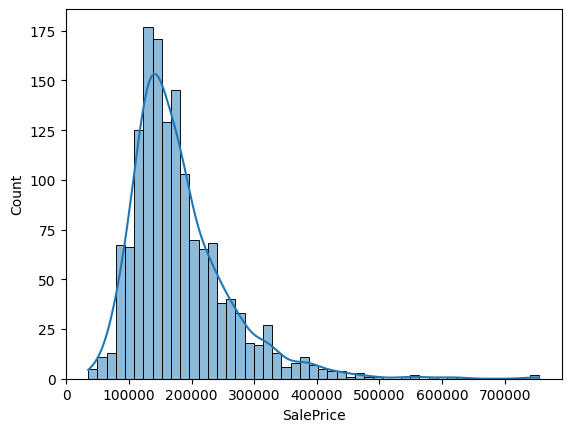

In [35]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

In [36]:
df['SalePrice'].skew()

np.float64(1.8828757597682129)

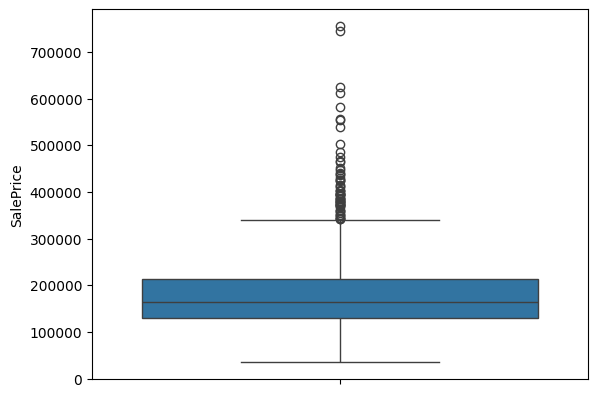

In [37]:
sns.boxplot(df['SalePrice'])
plt.show()

#### Key Findings

The target variable (SalePrice) exhibits a strong positive skew, with a small number of high-value properties extending the upper tail of the distribution. This is reflected by the noticeable gap between the mean and median sale prices and confirmed by a skewness value of approximately 1.88.

The boxplot identifies several statistical outliers on the upper end of the price range. However, given the nature of the housing market, these observations are likely to represent legitimate luxury properties rather than data quality issues. These records will be investigated further before any decision is made regarding their treatment.

The skewed target distribution may influence certain regression models by causing large-valued observations to contribute disproportionately to the learning process. A logarithmic transformation of SalePrice may therefore be explored during model development and validated using unseen data.

## 2. Numerical Feature Analysis

### GrLivArea

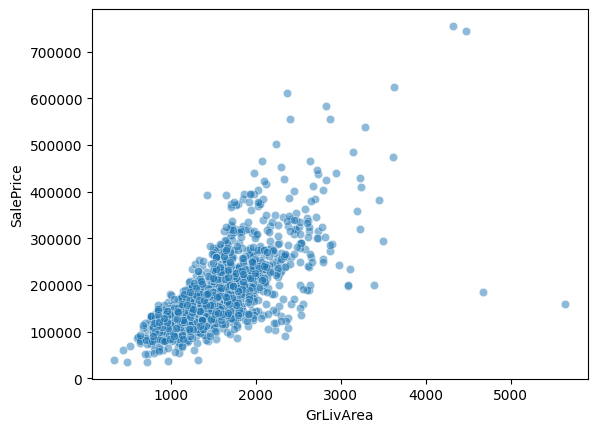

In [8]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.5 )
plt.show()

#### Key Findings

Ground Living Area (GrLivArea) demonstrates a strong positive relationship with SalePrice, indicating that larger homes generally command higher market values. Most observations follow a clear upward trend, suggesting that living area is likely to be an important predictor of house price.

A small number of properties exhibit exceptionally large living areas while selling for relatively low prices compared to similarly sized homes. These observations deviate from the general pattern and may represent influential outliers. Further investigation is required to determine whether they reflect legitimate market conditions or anomalous records.

### TotalBsmtSF

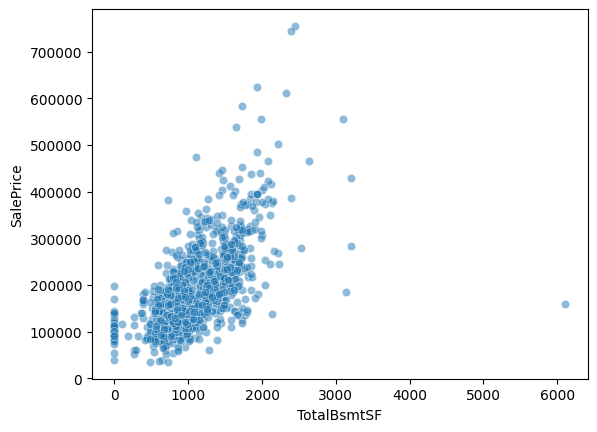

In [9]:
sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice', alpha=0.5)
plt.show()

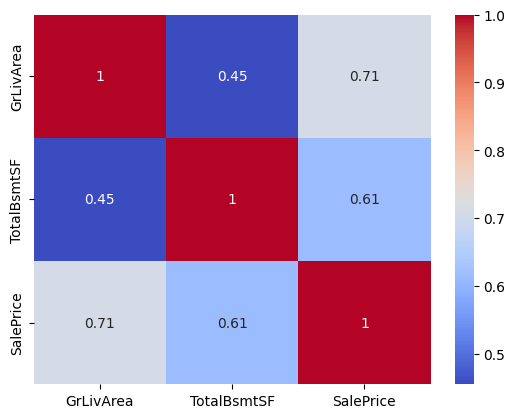

In [10]:
corr_matrix=df[['GrLivArea', 'TotalBsmtSF', 'SalePrice']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

#### Key Findings

The scatter plot reveals a distinct group of houses with zero basement area, indicating that the presence of a basement may itself contribute valuable information beyond its size.

Total Basement Area (TotalBsmtSF) shows a strong positive relationship with SalePrice, suggesting that larger basement spaces are generally associated with higher property values. Most high-priced homes appear to contain substantial basement areas, while properties without basements are concentrated in the lower price ranges.

Additionally, a small number of properties exhibit unusually large basement areas while maintaining relatively modest sale prices. These observations deviate from the overall trend and warrant further investigation during subsequent analysis.

Although both GrLivArea and TotalBsmtSF represent aspects of property size, the correlation between them is only moderate (~0.45). This suggests that basement area provides information that is not fully captured by above-ground living space and may therefore contribute additional predictive value during model development.

## 3. Ordinal Feature Analysis

### OverallQual

In [11]:
df.OverallQual.value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

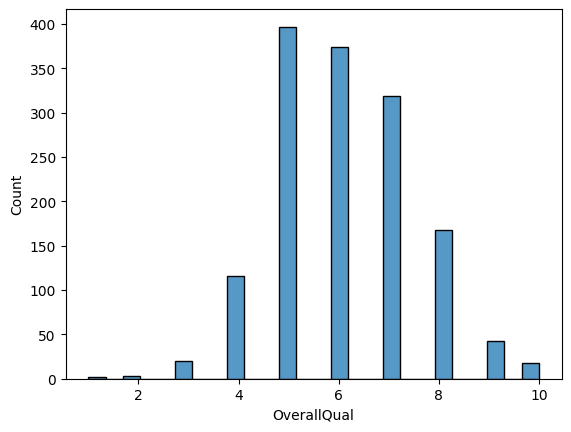

In [12]:
sns.histplot(data=df, x='OverallQual')
plt.show()

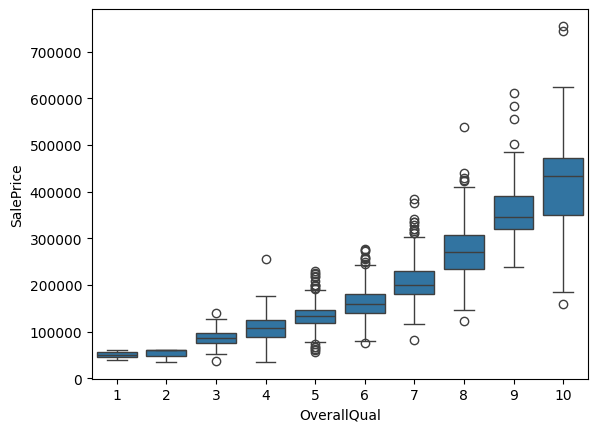

In [13]:
sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)
plt.show()

In [ ]:
df['OverallQual'].corr(df['SalePrice'])

np.float64(0.7909816005838052)

#### Key Findings

average quality homes dominate the dataset

So far OverallQual exhibits one of the strongest relationships with SalePrice in the dataset (correlation ≈ 0.79). The boxplot reveals a clear upward shift in the median sale price as quality ratings increase, indicating that higher-quality homes consistently command higher market values.

Additionally, higher quality categories exhibit greater variability in sale prices, suggesting that while quality is a major determinant of value, other factors continue to influence pricing within each quality tier

### GarageCars

In [15]:
df.GarageCars.value_counts().sort_index(ascending=False)

GarageCars
4      5
3    181
2    824
1    369
0     81
Name: count, dtype: int64

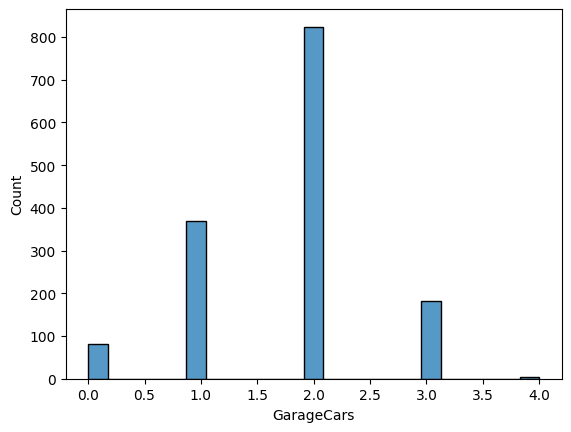

In [16]:
sns.histplot(data=df, x='GarageCars')
plt.show()

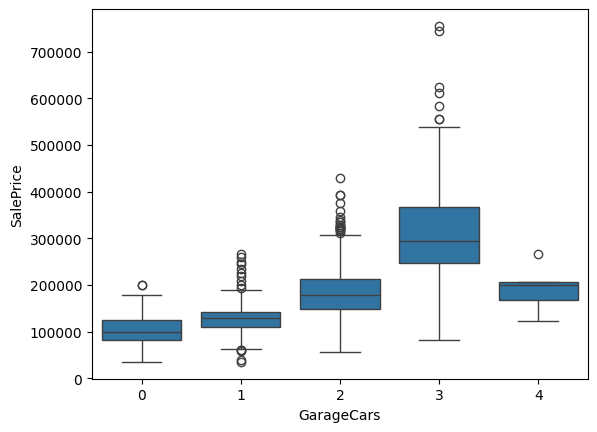

In [38]:
sns.boxplot(data=df,
                x='GarageCars',
                y='SalePrice')
plt.show()

In [18]:
df["GarageCars"].corr(df["SalePrice"])

np.float64(0.6404091972583522)

#### Key Findings

GarageCars exhibits a moderately strong positive relationship with SalePrice (correlation ≈ 0.64). The boxplot suggests that median house prices generally increase as garage capacity increases, indicating that larger garage capacities are associated with higher-valued properties. Although the highest category (4-car garages) does not fully follow this trend, the small number of observations in this group suggests that the apparent deviation may be due to limited sample size rather than a meaningful market pattern.

## 4. Neighborhood Analysis

### Neighborhood vs SalePrice

In [19]:
neighborhood_order =df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
neighborhood_order

Index(['MeadowV', 'IDOTRR', 'BrDale', 'OldTown', 'Edwards', 'BrkSide',
       'Sawyer', 'Blueste', 'SWISU', 'NAmes', 'NPkVill', 'Mitchel', 'SawyerW',
       'Gilbert', 'NWAmes', 'Blmngtn', 'CollgCr', 'ClearCr', 'Crawfor',
       'Veenker', 'Somerst', 'Timber', 'StoneBr', 'NoRidge', 'NridgHt'],
      dtype='object', name='Neighborhood')

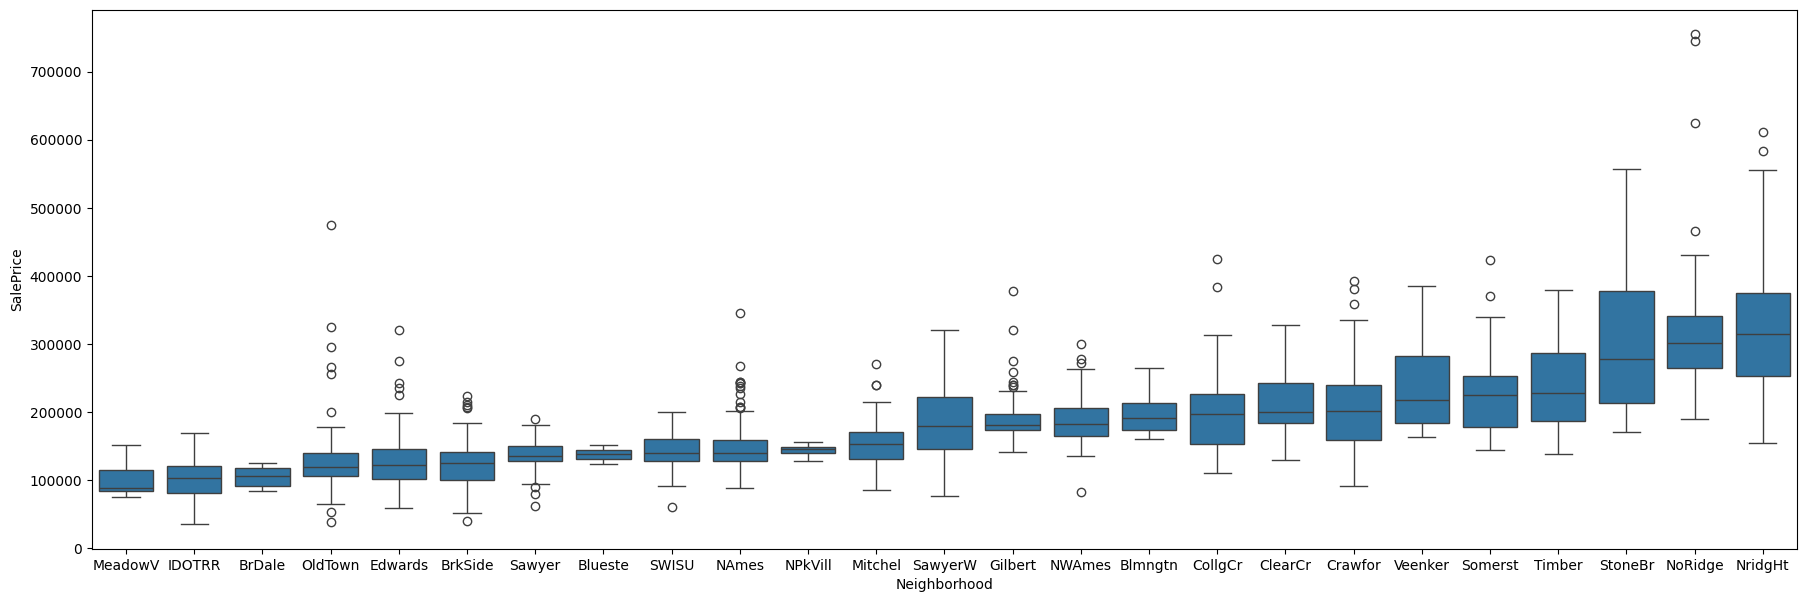

In [20]:
plt.figure(figsize=(22,7))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=neighborhood_order, )
plt.show()

In [21]:
neighborhood_medians = (
    df.groupby("Neighborhood")["SalePrice"]
      .median()
      .sort_values()
)

print(neighborhood_medians)

Neighborhood
MeadowV     88000.0
IDOTRR     103000.0
BrDale     106000.0
OldTown    119000.0
Edwards    121750.0
BrkSide    124300.0
Sawyer     135000.0
Blueste    137500.0
SWISU      139500.0
NAmes      140000.0
NPkVill    146000.0
Mitchel    153500.0
SawyerW    179900.0
Gilbert    181000.0
NWAmes     182900.0
Blmngtn    191000.0
CollgCr    197200.0
ClearCr    200250.0
Crawfor    200624.0
Veenker    218000.0
Somerst    225500.0
Timber     228475.0
StoneBr    278000.0
NoRidge    301500.0
NridgHt    315000.0
Name: SalePrice, dtype: float64


#### Key Findings

There are clear differences in house prices across neighborhoods. Most neighborhoods show a gradual increase in median sale price, while a few neighborhoods such as StoneBr, NoRidge, and NridgHt stand out with much higher prices.

These results suggest that location has a strong influence on SalePrice. Therefore, Neighborhood may provide valuable information for predicting house prices.

### Neighborhood Sample Size Review

In [22]:
df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

#### Key Findings

When interpreting the neighborhood analysis, it is important to consider the distribution of observations across neighborhoods. Most houses are concentrated in neighborhoods such as NAmes, CollgCr, OldTown, and Edwards, while several neighborhoods contain relatively few observations. Although StoneBr, NoRidge, and NridgHt appear to form a premium-priced group, this conclusion should be interpreted with some caution, particularly for neighborhoods with smaller sample sizes such as StoneBr. Further analysis may help determine whether these differences reflect true market segments or are partly influenced by limited observations.


## 5. Correlation and Feature Relationship Analysis

In [23]:
matrix=df.select_dtypes(include=np.number).corr()
matrix['SalePrice'].sort_values(ascending=False).head(20)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64

The correlation analysis identifies OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), and TotalBsmtSF (0.61) as the strongest numerical predictors of SalePrice. These results align closely with earlier visual analyses, confirming that property quality, living space, garage capacity, and basement area are key factors associated with house value.

Several groups of related features emerge from the ranking. Features describing property size (GrLivArea, TotalBsmtSF, 1stFlrSF, TotRmsAbvGrd) and garage characteristics (GarageCars, GarageArea, GarageYrBlt) all exhibit relatively strong correlations with SalePrice. This suggests that multiple features may capture similar underlying concepts, warranting further investigation for potential multicollinearity during subsequent analysis.

Additionally, construction and renovation-related variables such as YearBuilt and YearRemodAdd show moderately strong positive correlations, indicating that newer and recently improved properties generally command higher sale prices.

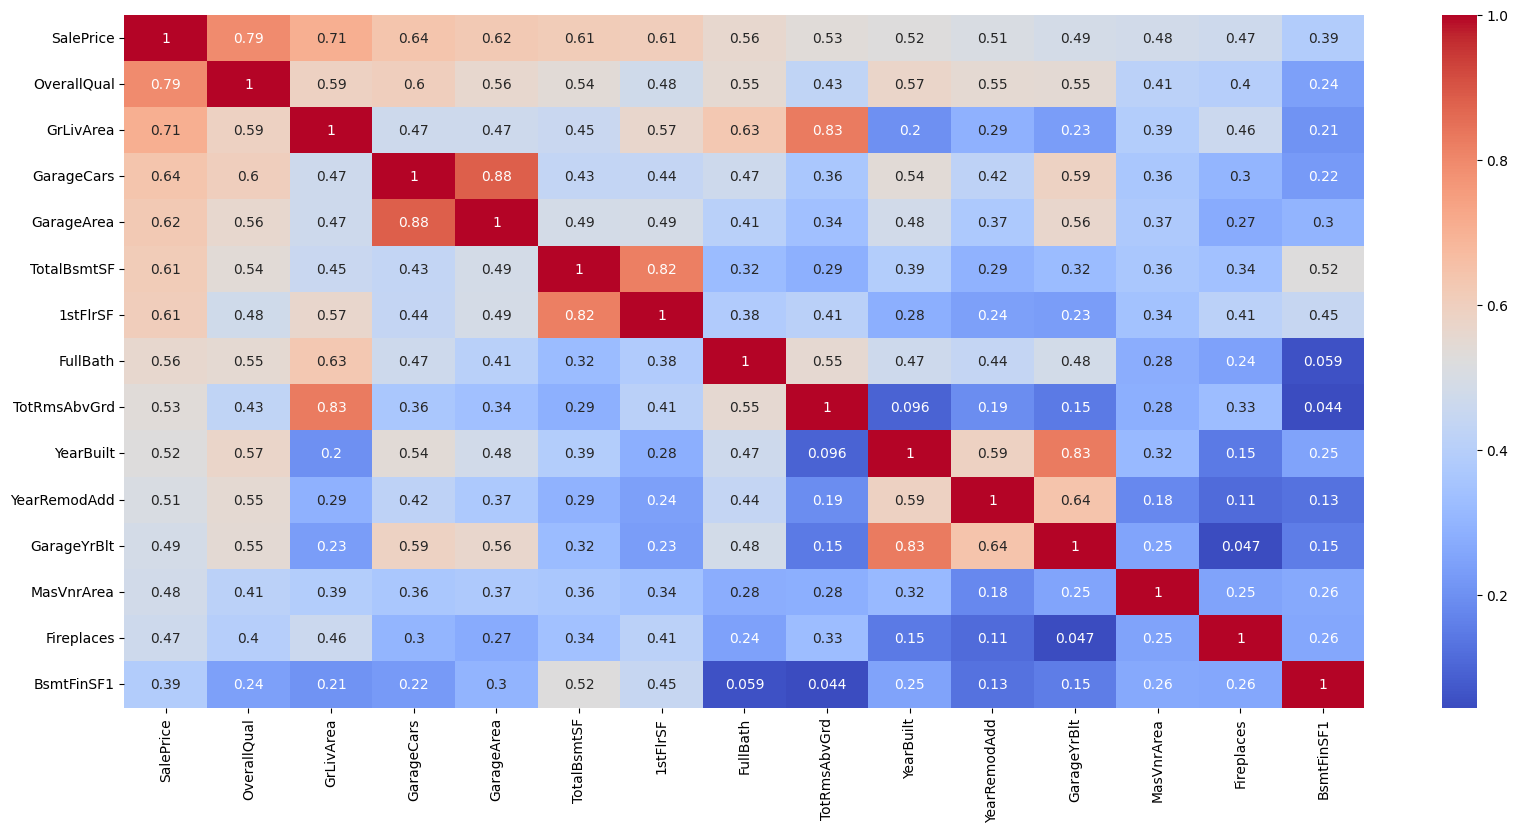

In [24]:
top_features = matrix['SalePrice'].abs().sort_values(ascending=False).head(15).index
corr_top = df[top_features].corr()

# mask = np.triu(np.ones_like(corr_top, dtype=bool))


plt.figure(figsize=(20,9))
sns.heatmap(corr_top, cmap='coolwarm', annot=True,)
plt.show()

To better understand the relationships among the most influential numerical features, a correlation heatmap was generated using the top 15 features most strongly associated with SalePrice.

### Feature Families

Several groups of highly correlated variables can be observed. For example, GarageCars and GarageArea exhibit a very strong positive correlation, indicating that larger garages generally accommodate more vehicles. Similarly, 1stFlrSF and TotalBsmtSF are strongly correlated, which is reasonable since many homes have basements with footprints similar to their first floors. Another notable relationship is between YearBuilt and GarageYrBlt, suggesting that garages are often constructed at the same time as the main house.

The heatmap also reveals broader feature families representing underlying business concepts such as property size (GrLivArea, 1stFlrSF, TotalBsmtSF, TotRmsAbvGrd), garage characteristics (GarageCars, GarageArea, GarageYrBlt), and property age or modernity (YearBuilt, YearRemodAdd). These clusters suggest that some variables may contain overlapping information, which could indicate potential multicollinearity in certain modeling approaches.

1. Size Family
* GrLivArea
* TotalBsmtSF
* 1stFlrSF*
* TotRmsAbvGrd
2. Garage Family
* GarageCars
* GarageArea
* GarageYrBlt
3. Modernity Family
* YearBuilt
* YearRemodAdd
4. Outdoor Space Family
* LotArea
* OpenPorchSF
* WoodDeckSF

### Outdoor Space Family

In [25]:
matrix["SalePrice"][["LotArea"]]

LotArea    0.263843
Name: SalePrice, dtype: float64

LotArea exhibits a positive but relatively weak linear relationship with SalePrice. While larger lots tend to be associated with higher prices, the relationship is substantially weaker than that observed for features such as OverallQual and GrLivArea. This suggests that land size alone may not be a primary driver of house prices and that buyers may place greater emphasis on factors such as living space, quality, and location.

In [27]:
matrix["SalePrice"][[
    "LotArea",
    "OpenPorchSF",
    "WoodDeckSF"
]].sort_values(ascending=False)

WoodDeckSF     0.324413
OpenPorchSF    0.315856
LotArea        0.263843
Name: SalePrice, dtype: float64

Outdoor space features show a weak positive relationship with SalePrice. Decks and porches are slightly more important than lot size, but all have much weaker effects than OverallQual and GrLivArea.

## 6. Missing Value Analysis

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(25)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
LandSlope          0
LotConfig          0
Condition1         0
dtype: int64

Several features contain missing values, with PoolQC, MiscFeature, Alley, Fence, and FireplaceQu having the most. In many cases, these missing values likely mean the property does not have that feature rather than indicating missing data. The same pattern is seen in garage and basement related features, where missing values may represent houses without a garage or basement. 

However, features such as LotFrontage, MasVnrArea, and Electrical require further investigation to determine whether the missing values represent actual missing data or have a specific meaning.

In [31]:
df["MasVnrType"].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [32]:
df["MasVnrArea"].describe()

count    1452.000000
mean      103.685262
std       181.066207
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1600.000000
Name: MasVnrArea, dtype: float64

MasVnrType contains a large number of missing values, while more than half of the houses have a MasVnrArea of 0. This suggests that many of the missing values may indicate the absence of masonry veneer rather than missing data. However, the small number of missing values in MasVnrArea should be investigated further before deciding how to handle them.

In [33]:
df['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

LotFrontage contains 259 missing values. Unlike features such as PoolQC or GarageType, it is not immediately obvious whether these missing values represent the absence of a property characteristic or genuinely missing information. Further investigation will be required before deciding how these values should be handled during data cleaning.

## 7. EDA Summary

### Major Findings

#### Target Variable
* SalePrice exhibits positive skewness.
* A small number of expensive properties create a long right tail.
#### Property Characteristics
* OverallQual is the strongest predictor identified during EDA.
* Larger homes generally sell for higher prices.
* Living area appears more influential than lot size.
#### Location
* Neighborhood has a substantial influence on house prices.
* Certain neighborhoods appear to command premium prices.
#### Feature Relationships
* Multiple feature families were identified.
* Potential multicollinearity exists among several related variables.
#### Data Quality
* Missing values often represent the absence of a property feature rather than missing information.
* Some variables require further investigation before cleaning decisions are made.


Insights gathered during this step will now guide the preprocessing and modeling stages of the project. The next step will involve preparing the data for modeling, including handling missing values, encoding categorical variables, and scaling numerical features as necessary.